# Proof of concept: Diffuse Correlation Spectroscopy
This notebook aims to replicate the measurements in the article titled _"Massively parallel, real-time multispeckle diffuse correlation spectroscopy using a 500 x 500 SPAD camera". 
Temporal auto-correlation ($g^{2}(\tau) = \frac{\langle n(t) n(t+\tau) \rangle}{\langle n(t)^2 \rangle}$) measurements are the central results of the article. 
The measurements are summarized in the following points: 
* The $g^{(2)} (\tau)$ and $\bar{g}^{(2)} (\tau)$ are calculated over *160* integration periods. 
    *  Loop over "decorrelation_24ch" save data for individual pixels and for the average. 
* STD is then calculated for a given $\tau$ bin. Paper reports $STD(g^{(2)} (10.8\mu s))=0.123$ and $STD(\bar{g}^{(2)}_{2.5e5} (10.8 \mu s))=2.6e-4$ 
* $SNR(g^{(2)} (\tau)) = mean_{160}(g^{(2)} (\tau)-1) / STD_{160}(g^{(2)} (\tau))$


## 1) Experimental Parameters 
The article reports the following experimental parameters: 
* Wavelenght $\lambda = 785 nm$ 
* Power $1 nW$
* PDP $15%$
* n-bins: 16
* Frame rate 93 fps. Exposure time $10.81 \mu s$
* Integration time 50 ms. Upper limit of $2^{16}$ exposures ($2^{16} = cps * T_{INT}$). 
* Pixel Diameter: $6\mu m$ similar to Speckle Diameter.
    * Pitch $16.38 \mu m$, Fill factor $10.6 \% $, circular active area, $z=11.5mm$

In [10]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from IPython.display import clear_output
import math

# DCS Parameters
t_int_ps = 8e12 # ps (e12 = seconds)
bin_width = 1_000e6 # ps (e6 = micro seconds)
n_bins = 21
num_periods = 10         # Number of frames to capture
target_bin = 1            # Index for the target tau bin (e.g., tau = 10.8 us)

# Calibration Parameters
t_exp_ps = 50e9 # exposure time
pixel_pitch_um = 125.0 # um 

## 2) Time Tagger Initialization
Connect to the Swabian Time Tagger hardware, configure the required input channels, and create a reference list for the active time-to-digital converters (TDC).

In [12]:
# Create Tagger Object and define available channels
print(f"Serial Numbers:{tt.scanTimeTagger()}") # Extract serial numbers
tagger = tt.createTimeTagger() # Create time tagger
spad_channels = np.array(tagger.getChannelList()) # Available Channels
spad_channels = spad_channels[spad_channels > 0] # Keep rising edges only (positive ch)

print(f"{len(spad_channels)} Available Channels : {spad_channels}") # Extract Channel List

Serial Numbers:()
36 Available Channels : [101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218]


## 3) Calibration: Contrate
Initialize a `CountRate` measurement instance using `spad_channels`. Display a live, updating plot of the count rates to adjust optical attenuation for optimal countrates. 

* Average detections per exposure $\langle n \rangle = 0.1$ with $T_{EX} = 10.81 \mu s$ == $9.25 kcps$


In [13]:
# block uses: t_exp_ps
# Create Countrate object
cr = tt.Countrate(tagger, channels=spad_channels)

channel_labels = [str(ch) for ch in spad_channels]

try:
    for _ in range(1000): #Define number of updates
        # Measure Countrates from object
        cr.startFor(t_exp_ps,clear=True)
        cr.waitUntilFinished()
        rates = cr.getData()
        #Visualize (Histogram)
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.bar(channel_labels, rates, color='cadetblue', edgecolor='black')
        plt.ylim(0,1.5e6) # Adjust limit to expected countrates
        plt.title("Live SPAD Line Sensor Count Rates")
        plt.xlabel("SPAD Channel")
        plt.ylabel("Counts per second (cps)")
        plt.xticks(channel_labels)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
except KeyboardInterrupt:
    print("Monitor interrupted.")

Monitor interrupted.


## 4)  Calibration: Speckle Size Measurement
Incident laser light on a scattering medium () produce a random interference effect also known as a speckle field. 
Capturing a count rate frame across the SPAD array in front of the diffuser generates a "picture" of the speckle field. 
To ensure individual pixels capture a single speckle, a calculation the spatial autocorrelation of the intensity pattern using `numpy.correlate` is done.
The Full Width at Half Maximum (FWHM) of the correlation peak to define the average speckle size. 

--- Speckle Size Calibration Results ---
100-Series Row: FWHM = 4.85 pixels | Physical Size = 606.4 µm
200-Series Row: FWHM = 4.74 pixels | Physical Size = 592.3 µm


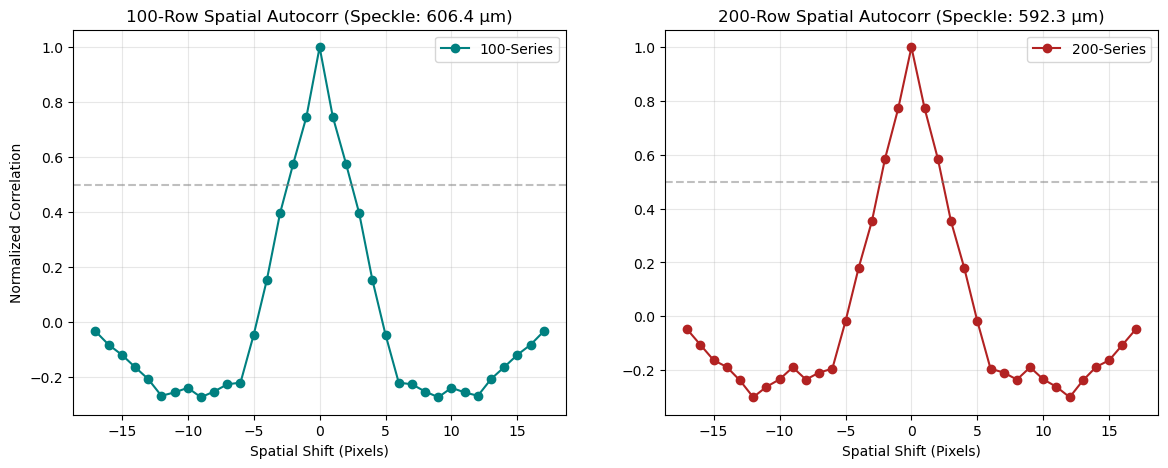

In [14]:
# block uses: t_exp_ps
cr =tt.Countrate(tagger,spad_channels)
cr.startFor(t_exp_ps, clear=True)
cr.waitUntilFinished()
rates = cr.getData()

# Map channels to countrates
rates_map = dict(zip(spad_channels,rates))

# Separate channels 
row_100 = spad_channels[spad_channels<199]
row_200 = spad_channels[spad_channels>199]

# Compute spatial autocorrelation
def spatial_autocorr_with_fwhm(row):
    if len(row) > 0:
        rates = np.array([rates_map[ch] for ch in row])
        fluc = rates - np.mean(rates)
        autocorr = np.correlate(fluc, fluc, mode='full')

        if np.max(autocorr) > 0:
            autocorr = autocorr / np.max(autocorr)

        shifts = np.arange(-len(row) + 1, len(row))
        
        # FWHM Calculation
        above_half = np.where(autocorr >= 0.5)[0]    # indices where the correlation is above 0.5
        
        if len(above_half) > 0:
            # Left crossing interpolation
            left_idx = above_half[0]
            if left_idx > 0:
                x0, x1 = shifts[left_idx - 1], shifts[left_idx]
                y0, y1 = autocorr[left_idx - 1], autocorr[left_idx]
                left_cross = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
            else:
                left_cross = shifts[left_idx]

            # Right crossing interpolation
            right_idx = above_half[-1]
            if right_idx < len(autocorr) - 1:
                x0, x1 = shifts[right_idx], shifts[right_idx + 1]
                y0, y1 = autocorr[right_idx], autocorr[right_idx + 1]
                right_cross = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
            else:
                right_cross = shifts[right_idx]

            fwhm_pixels = right_cross - left_cross
        else:
            fwhm_pixels = 0.0

        return autocorr, shifts, fwhm_pixels
    else:
        print("Error: Empty row provided.")
        return None, None, 0.0

# Extract data and FWHM
autocorr_100, shifts_100, fwhm_100 = spatial_autocorr_with_fwhm(row_100)
autocorr_200, shifts_200, fwhm_200 = spatial_autocorr_with_fwhm(row_200)

# Calculate physical speckle sizes
speckle_size_100_um = fwhm_100 * pixel_pitch_um
speckle_size_200_um = fwhm_200 * pixel_pitch_um

print(f"--- Speckle Size Calibration Results ---")
print(f"100-Series Row: FWHM = {fwhm_100:.2f} pixels | Physical Size = {speckle_size_100_um:.1f} µm")
print(f"200-Series Row: FWHM = {fwhm_200:.2f} pixels | Physical Size = {speckle_size_200_um:.1f} µm")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if autocorr_100 is not None:
    ax1.plot(shifts_100, autocorr_100, marker='o', color='teal', label='100-Series')
    ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f"100-Row Spatial Autocorr (Speckle: {speckle_size_100_um:.1f} µm)")
    ax1.set_xlabel("Spatial Shift (Pixels)")
    ax1.set_ylabel("Normalized Correlation")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

if autocorr_200 is not None:
    ax2.plot(shifts_200, autocorr_200, marker='o', color='firebrick', label='200-Series')
    ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax2.set_title(f"200-Row Spatial Autocorr (Speckle: {speckle_size_200_um:.1f} µm)")
    ax2.set_xlabel("Spatial Shift (Pixels)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.show()

## 5) Diffuse Correlation Spectroscopy
* The $g^{(2)} (\tau)$ and $\bar{g}^{(2)} (\tau)$ are calculated over *160* integration periods. 
    *  Loop over "decorrelation_24ch" save data for individual pixels and for the average. 
* STD is then calculated for a given $\tau$ bin. Paper reports $STD(g^{(2)} (10.8\mu s))=0.123$ and $STD(\bar{g}^{(2)}_{2.5e5} (10.8 \mu s))=2.6e-4$ 
* $SNR(g^{(2)} (\tau)) = mean_{160}(g^{(2)} (\tau)-1) / STD_{160}(g^{(2)} (\tau))$

In [15]:
# Measurement function
def measure_autocorrelation(tagger, channels, t_int_ps, bin_width, n_bins, periods=160):
    """
    Measures autocorrelation histograms of all channels over a number of periods.
    """
    num_ch = len(channels)
    raw_hists = np.zeros((periods, num_ch, n_bins))
    tau_axis = None

    print(f"Start {periods} measurement periods...")

    for p in range(periods):
        correlations = []
        
        # Initialize correlation objects
        for ch in channels:
            corr = tt.Correlation(tagger, ch, ch, binwidth=bin_width, n_bins=n_bins)
            correlations.append(corr)

        # Start hardware clock
        tagger.sync()
        for corr in correlations:
            corr.startFor(t_int_ps, clear=True)

        # Wait and extract raw data
        for i, corr in enumerate(correlations):
            corr.waitUntilFinished()
            hist = corr.getData()
            
            if tau_axis is None:
                tau_axis = corr.getIndex()
            
            raw_hists[p, i, :] = hist

    print("Measurement complete. Raw histograms extracted.")
    return tau_axis, raw_hists

In [16]:
# Run the function
tau_axis, raw_hists = measure_autocorrelation(
    tagger=tagger, 
    channels=spad_channels, 
    t_int_ps=t_int_ps, 
    bin_width=bin_width, 
    n_bins=n_bins, 
    periods=num_periods
)

Start 10 measurement periods...
Measurement complete. Raw histograms extracted.


Plotting raw histograms for period 0...


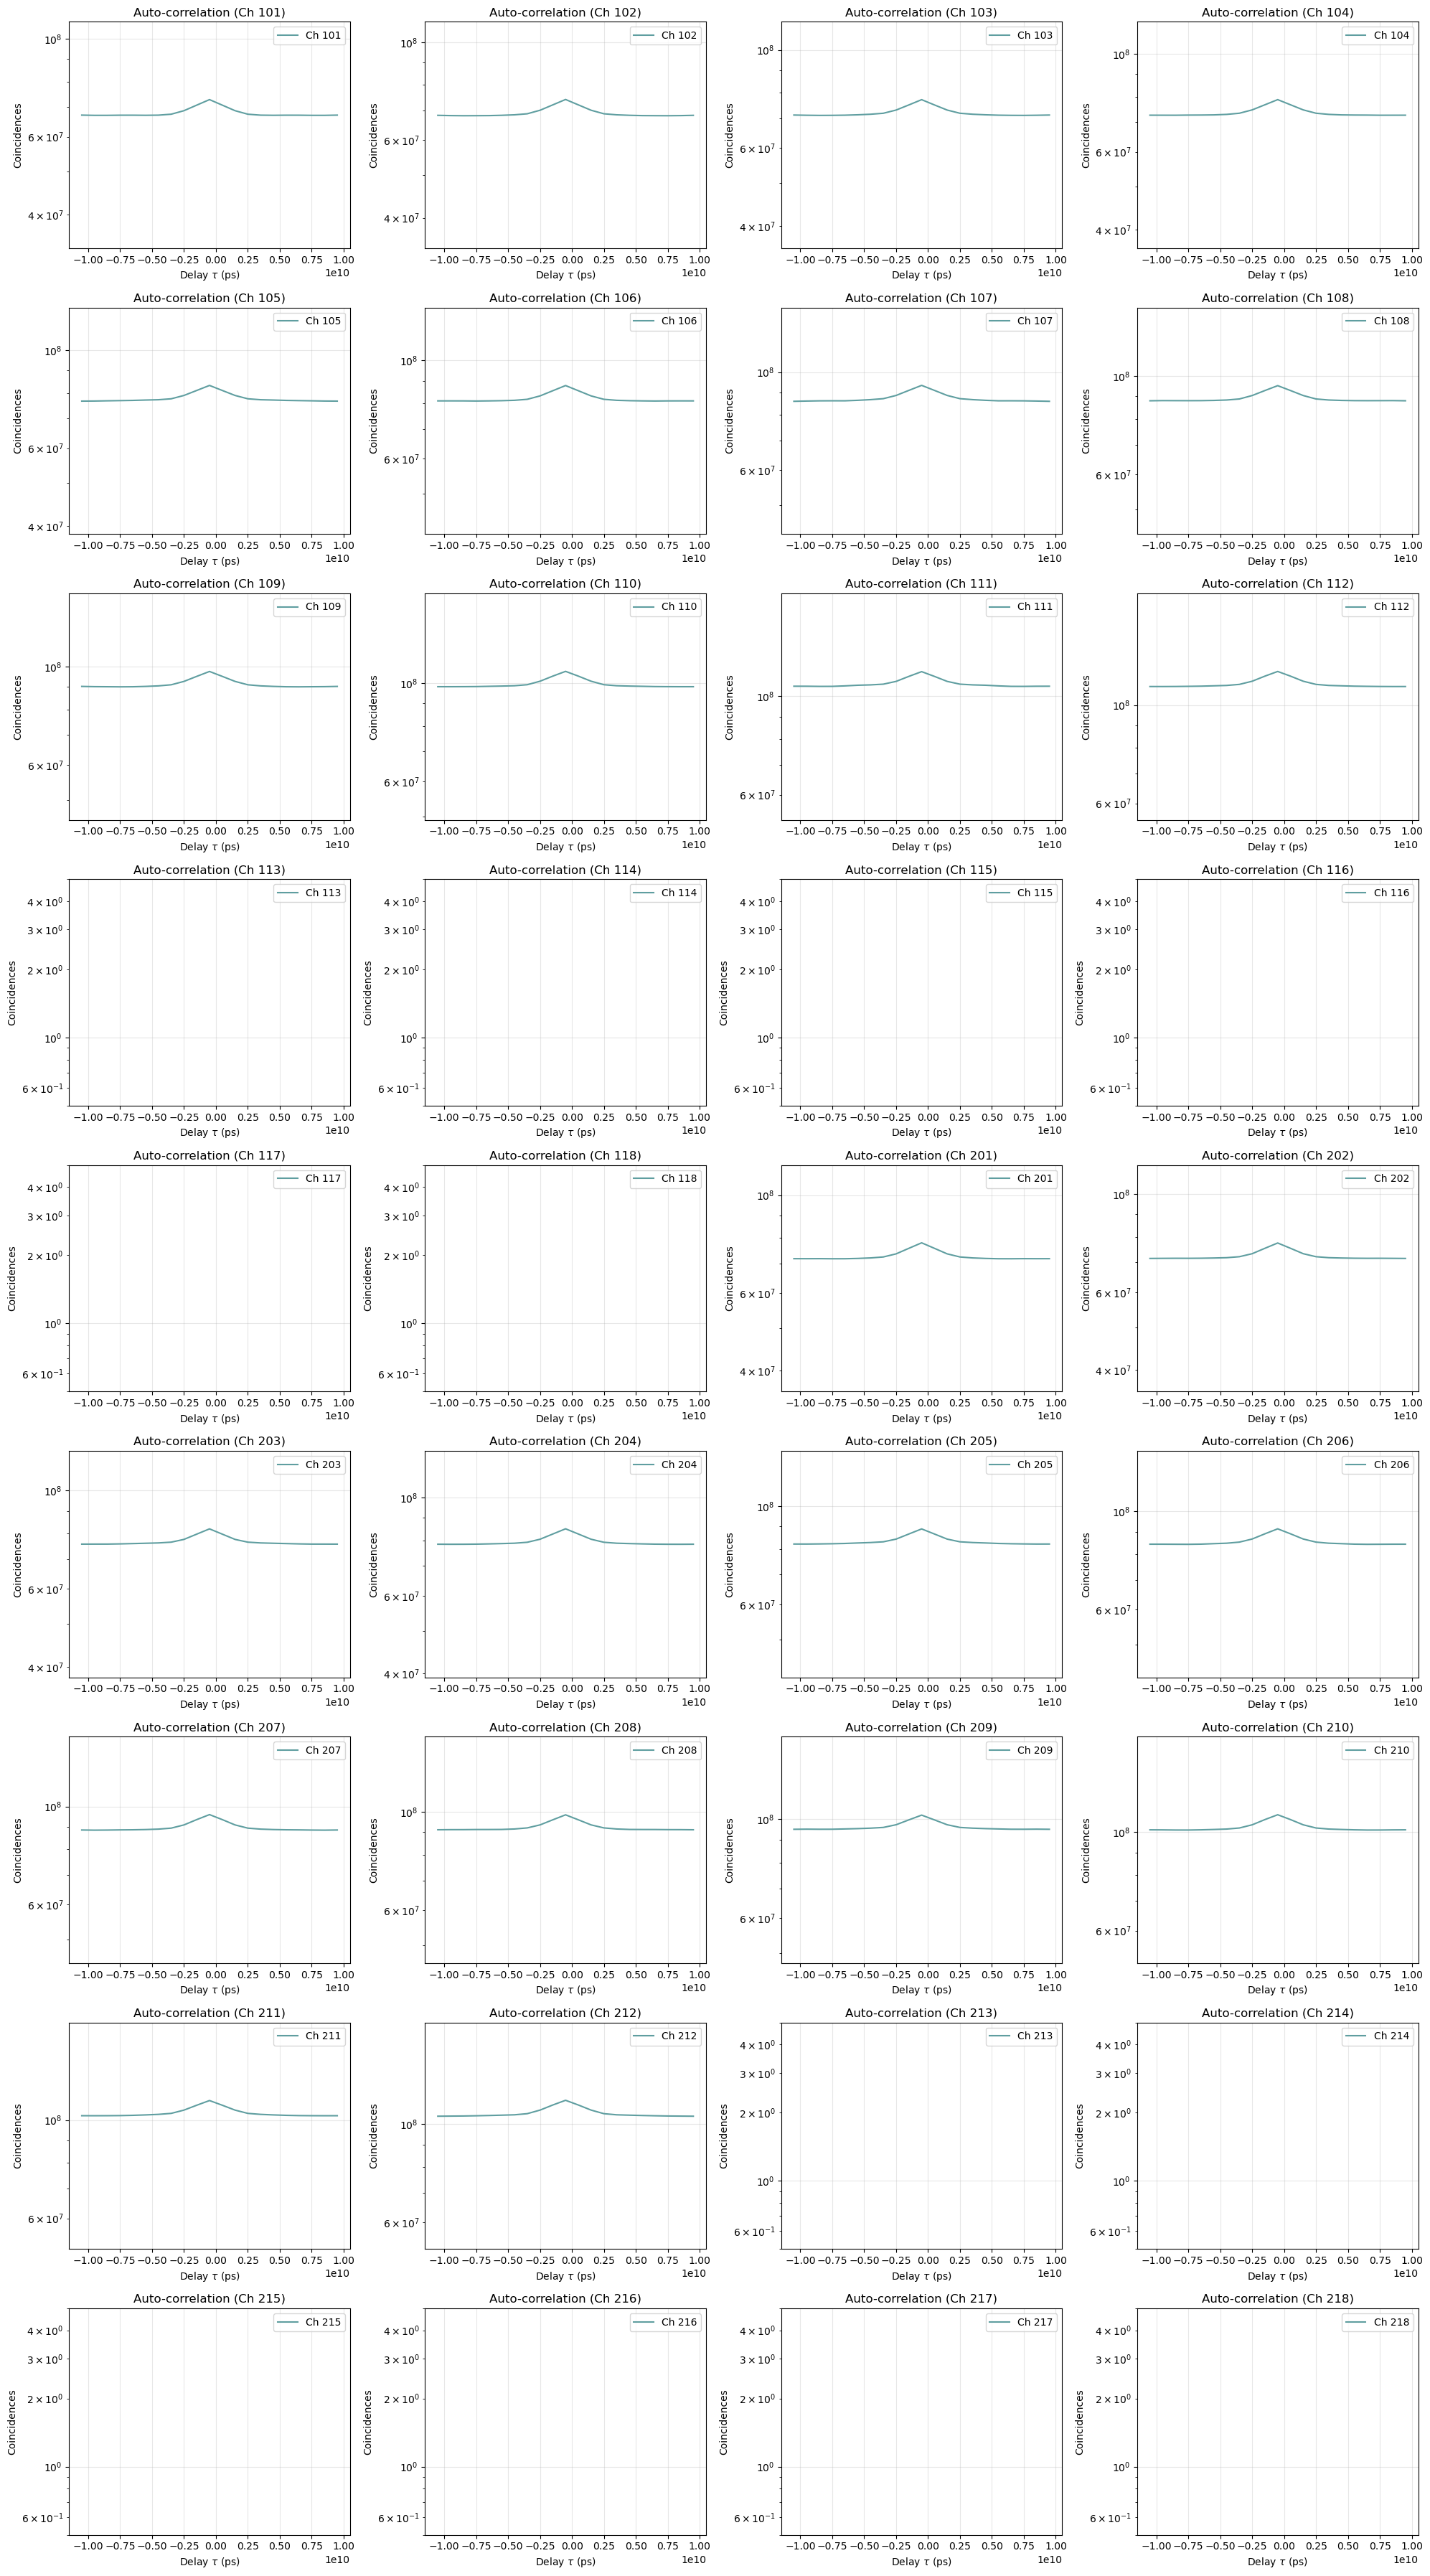

In [17]:
# Prelim: Visualization
import math

# Select the integration period to show (index starts at 0)
plot_period = 0

print(f"Plotting raw histograms for period {plot_period}...")

num_plots = len(spad_channels)
cols = min(4, num_plots)
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.atleast_1d(axes).flatten()

for idx, ch in enumerate(spad_channels):
    ax = axes[idx]
    t_plot = tau_axis  # Time delay in picoseconds
    hist_plot = raw_hists[plot_period, idx, :]
    
    # Calculate baseline from the last 10 percent of the histogram
    tail_length = int(len(hist_plot) * 0.1)
    if tail_length == 0:
        tail_length = 1
        
    baseline_avg = np.mean(hist_plot[-tail_length:])
    
    # Prevent errors with the logarithmic scale
    if baseline_avg <= 0:
        baseline_avg = 1.0
        
    y_min = baseline_avg * 0.50
    y_max = np.max(hist_plot) * 1.50
    
    if y_max <= y_min:
        y_max = y_min * 10

    ax.plot(t_plot, hist_plot, color='cadetblue', linewidth=1.5, label=f'Ch {ch}')
    ax.set_ylim([y_min, y_max])
    ax.set_yscale('log')
    ax.set_title(f"Auto-correlation (Ch {ch})")
    ax.set_xlabel(r"Delay $\tau$ (ps)")
    ax.set_ylabel("Coincidences")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
# Hide the subplots that do not have data
for i in range(num_plots, len(axes)):
    axes[i].set_visible(False)
    
plt.tight_layout()
plt.show()

In [ ]:

#save
import os
import numpy as np
from datetime import datetime

# 1. Define the target directory
save_dir = "../data/raw/decorrelation"

# Create the directory if it does not exist
os.makedirs(save_dir, exist_ok=True)

# 2. Create a unique filename with a timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"raw_autocorr_{timestamp}.npz"
filepath = os.path.join(save_dir, filename)

# 3. Save the data arrays
print(f"Saving raw data to {filepath}...")
np.savez_compressed(
    filepath,
    tau_axis=tau_axis,
    raw_hists=raw_hists,
    channels=spad_channels
)

print("Data saved successfully.")

Saving raw data to .data/raw/decorrelation\raw_autocorr_20260807_200133.npz...
Data saved successfully.


Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization
Baseline = 0 ... skipping normalization


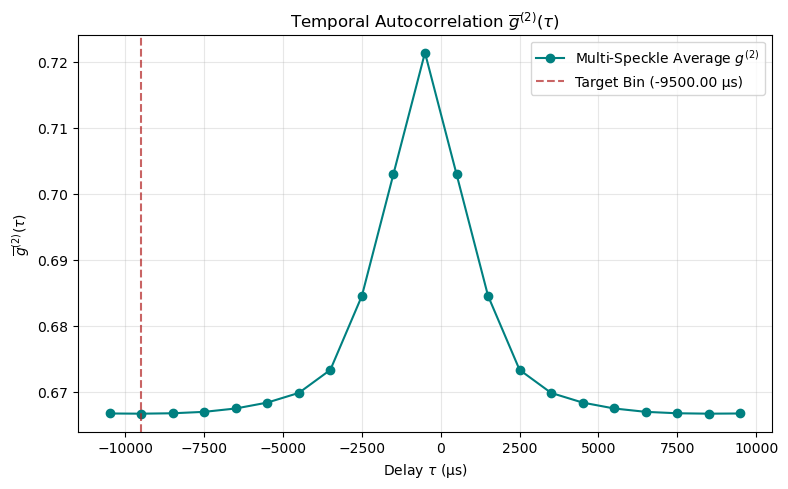

In [19]:

# Calculate Statistics 
num_ch = len(spad_channels)
g2_all = np.zeros_like(raw_hists, dtype=float)
g2_avg = np.zeros((num_periods, n_bins))

# Calculate g2 for each period and channel
for p in range(num_periods):
    for i in range(num_ch):
        hist = raw_hists[p, i, :]
        
        tail_length = int(n_bins * 0.1)
        if tail_length == 0:
            tail_length = 1
        
        baseline = np.mean(hist[-tail_length:])
        if baseline > 0:
            g2_all[p, i, :] = hist / baseline
        else:
            g2_all[p, i, :] = hist
            print("Baseline = 0 ... skipping normalization")
            
    # Calculate the spatial average across all pixels for this period
    g2_avg[p, :] = np.mean(g2_all[p, :, :], axis=0)

# Individual Pixels
mean_ind = np.mean(g2_all[:, :, target_bin] - 1, axis=0)
std_ind = np.std(g2_all[:, :, target_bin], axis=0)
snr_ind = np.divide(mean_ind, std_ind, out=np.zeros_like(mean_ind), where=std_ind!=0)

# Averaged Curve
mean_avg = np.mean(g2_avg[:, target_bin] - 1)
std_avg = np.std(g2_avg[:, target_bin])
snr_avg = mean_avg / std_avg if std_avg > 0 else 0

# Print Statistical Comparison

tau_value = tau_axis[target_bin]

print("\n--- SNR and STD Results ---")
print(f"Target Delay Bin: {tau_value / 1e6:.2f} µs")
print(f"Number of Integration Periods: {num_periods}")
print(f"Number of Pixels Averaged: {num_ch}\n")

avg_std_ind = np.mean(std_ind)
avg_snr_ind = np.mean(snr_ind)

print("INDIVIDUAL PIXEL (Average across array):")
print(f"  STD: {avg_std_ind:.4f}")
print(f"  SNR: {avg_snr_ind:.4f}\n")

print("MULTI-SPECKLE AVERAGE:")
print(f"  STD: {std_avg:.4f}")
print(f"  SNR: {snr_avg:.4f}")

# Visualization

tau_axis_us = tau_axis / 1e6  # Convert ps to us
g2_avg_final = np.mean(g2_avg, axis=0) # Mean of the averaged curves over 160 periods

plt.figure(figsize=(8, 5))

plt.plot(tau_axis_us, g2_avg_final, marker='o', color='teal', label='Multi-Speckle Average $g^{(2)}$')
plt.axvline(tau_axis_us[target_bin], color='firebrick', linestyle='--', alpha=0.7, label=f'Target Bin ({tau_axis_us[target_bin]:.2f} µs)')

plt.title("Temporal Autocorrelation $\overline{g}^{(2)}(\\tau)$")
plt.xlabel("Delay $\\tau$ (µs)")
plt.ylabel("$\overline{g}^{(2)}(\\tau)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()